<a href="https://colab.research.google.com/github/kailashscse2025-alt/DAA/blob/main/DAA3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


              KRUSKAL'S MST
Edge           Weight    
-------------------------
0 - 3         5
2 - 4         5
3 - 5         6
0 - 1         7
1 - 4         7
4 - 6         9
-------------------------
Total MST Cost = 39

                PRIM'S MST
Edge           Weight    
-------------------------
0 - 3         5
3 - 5         6
0 - 1         7
1 - 4         7
4 - 2         5
4 - 6         9
-------------------------
Total MST Cost = 39


/tmp/ipykernel_414/124677427.py:223: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


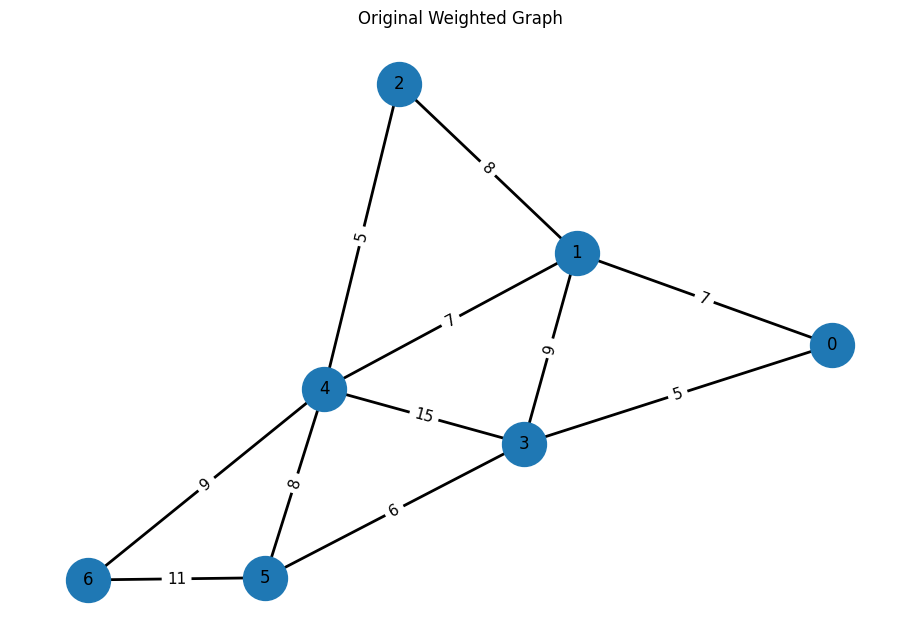

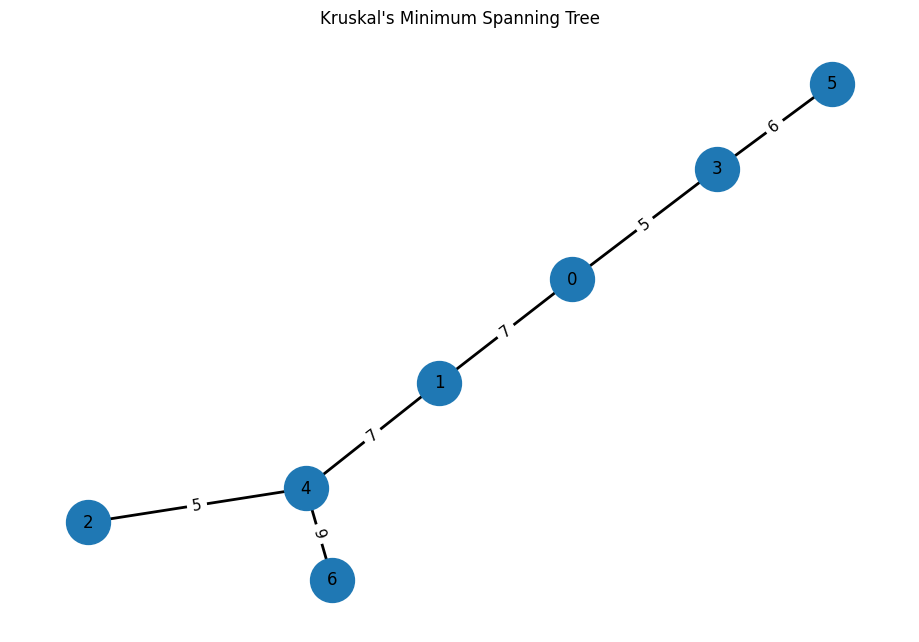

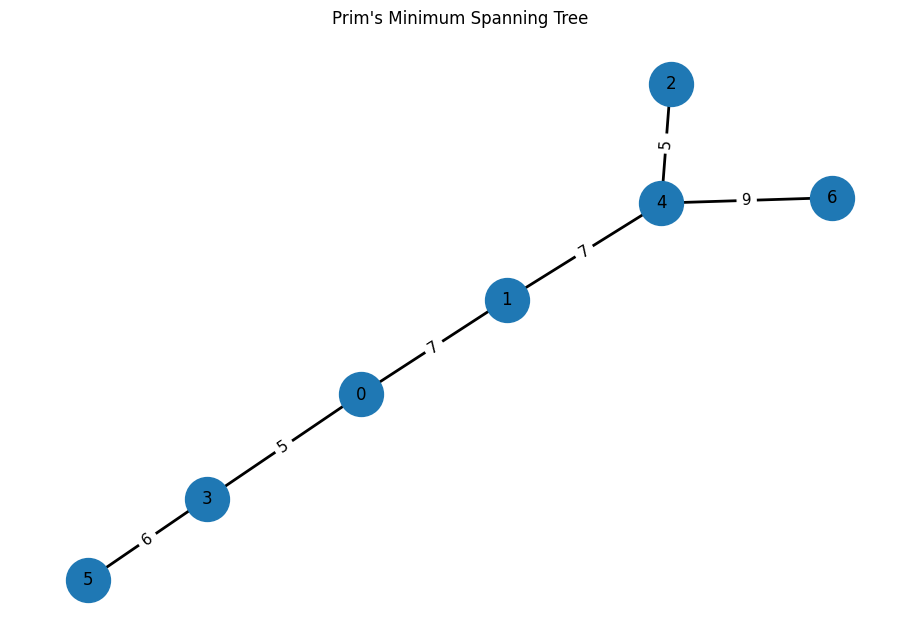

In [2]:
import heapq
import matplotlib.pyplot as plt
import networkx as nx


# ==========================================
# UNION-FIND FOR KRUSKAL
# ==========================================

class UnionFind:

    def __init__(self, n):
        self.parent = list(range(n))
        self.rank = [0] * n

    def find(self, x):
        if self.parent[x] != x:
            self.parent[x] = self.find(self.parent[x])
        return self.parent[x]

    def union(self, x, y):

        rx = self.find(x)
        ry = self.find(y)

        if rx == ry:
            return False

        if self.rank[rx] < self.rank[ry]:
            rx, ry = ry, rx

        self.parent[ry] = rx

        if self.rank[rx] == self.rank[ry]:
            self.rank[rx] += 1

        return True


# ==========================================
# KRUSKAL'S ALGORITHM
# ==========================================

def kruskal(n, edges):

    edges.sort()

    uf = UnionFind(n)

    mst = []
    cost = 0

    for w, u, v in edges:

        if uf.union(u, v):

            mst.append((u, v, w))
            cost += w

        if len(mst) == n - 1:
            break

    return mst, cost


# ==========================================
# PRIM'S ALGORITHM
# ==========================================

def prim(n, adj, start=0):

    INF = float('inf')

    key = [INF] * n
    parent = [-1] * n
    inMST = [False] * n

    key[start] = 0

    pq = [(0, start)]

    mst = []
    cost = 0

    while pq:

        w, u = heapq.heappop(pq)

        if inMST[u]:
            continue

        inMST[u] = True

        if parent[u] != -1:
            mst.append((parent[u], u, w))
            cost += w

        for v, wt in adj.get(u, []):

            if not inMST[v] and wt < key[v]:

                key[v] = wt
                parent[v] = u

                heapq.heappush(pq, (wt, v))

    return mst, cost


# ==========================================
# GRAPH
# ==========================================

n = 7

edges = [
    (7, 0, 1),
    (5, 0, 3),
    (8, 1, 2),
    (9, 1, 3),
    (7, 1, 4),
    (5, 2, 4),
    (15, 3, 4),
    (6, 3, 5),
    (8, 4, 5),
    (9, 4, 6),
    (11, 5, 6)
]


# ==========================================
# ADJACENCY LIST
# ==========================================

adj = {}

for w, u, v in edges:

    adj.setdefault(u, []).append((v, w))
    adj.setdefault(v, []).append((u, w))


# ==========================================
# RUN ALGORITHMS
# ==========================================

k_mst, k_cost = kruskal(n, edges[:])

p_mst, p_cost = prim(n, adj)


# ==========================================
# KRUSKAL TABLE
# ==========================================

print("\n==============================================")
print("              KRUSKAL'S MST")
print("==============================================")

print(f"{'Edge':<15}{'Weight':<10}")
print("-" * 25)

for u, v, w in k_mst:
    print(f"{u} - {v:<10}{w}")

print("-" * 25)
print(f"Total MST Cost = {k_cost}")


# ==========================================
# PRIM TABLE
# ==========================================

print("\n==============================================")
print("                PRIM'S MST")
print("==============================================")

print(f"{'Edge':<15}{'Weight':<10}")
print("-" * 25)

for u, v, w in p_mst:
    print(f"{u} - {v:<10}{w}")

print("-" * 25)
print(f"Total MST Cost = {p_cost}")


# ==========================================
# FUNCTION TO DRAW GRAPH
# ==========================================

def draw_graph(title, graph_edges):

    G = nx.Graph()

    for u, v, w in graph_edges:
        G.add_edge(u, v, weight=w)

    pos = nx.spring_layout(G, seed=42)

    plt.figure(figsize=(9, 6))

    nx.draw(
        G,
        pos,
        with_labels=True,
        node_size=1000,
        font_size=12,
        width=2
    )

    labels = nx.get_edge_attributes(G, 'weight')

    nx.draw_networkx_edge_labels(
        G,
        pos,
        edge_labels=labels,
        font_size=11
    )

    plt.title(title)
    plt.axis("off")
    plt.tight_layout()
    plt.show()


# ==========================================
# ORIGINAL GRAPH
# ==========================================

original_edges = [
    (u, v, w)
    for w, u, v in edges
]

draw_graph(
    "Original Weighted Graph",
    original_edges
)


# ==========================================
# KRUSKAL MST GRAPH
# ==========================================

draw_graph(
    "Kruskal's Minimum Spanning Tree",
    k_mst
)


# ==========================================
# PRIM MST GRAPH
# ==========================================

draw_graph(
    "Prim's Minimum Spanning Tree",
    p_mst
)